# FINd Optimised — Evaluation

This notebook evaluates **FINDHasher_optimized** (`FINd_optimized.py`) — the fully vectorised version of FINd applying all six NumPy optimisations. Following the same checks implemented in  `01_evaluation& ProfilingFINd.ipynb`.


---
## 0. Setup



In [ ]:
import sys
import io
import random
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageFilter, ImageEnhance

sys.path.insert(0, str(Path("../").resolve()))
from FINd_optimized import FINDHasher_optimized

random.seed(42)
np.random.seed(42)

hasher   = FINDHasher_optimized()
MEME_DIR = Path(".../Hilary_term /DS in practice TA/Summative /meme_images") # Update this path to your local directory containing the meme images
OUTPUT_DIR = Path("../output")
OUTPUT_DIR.mkdir(exist_ok=True)

all_images = sorted(MEME_DIR.glob("*.jpg"))

def family(path):
    return Path(path).stem.split("_")[0]

print(f"Images: {len(all_images):,}")
print(f"Hasher: {hasher.__class__.__name__}")

Images: 55,972
Hasher: FINDHasher_optimized


---
## Check 1 

In [2]:
test_images = random.sample(all_images, 20)

distances = []
for p in test_images:
    h1 = hasher.fromFile(str(p))
    h2 = hasher.fromFile(str(p))
    distances.append(h1 - h2)

all_zero = all(d == 0 for d in distances)
print(f"Images tested      : {len(test_images)}")
print(f"All distances zero : {all_zero}")
print(f"Result             : {'PASS' if all_zero else 'FAIL'}")

Images tested      : 20
All distances zero : True
Result             : PASS


---
## Check 2 — Robustness



In [3]:
def apply_transformations(img_path):
    img = Image.open(img_path).convert("RGB")
    transforms = {}
    buf = io.BytesIO()
    img.save(buf, format="JPEG", quality=50)
    buf.seek(0)
    transforms["JPEG q=50"] = Image.open(buf).copy()
    small = img.resize((img.width // 2, img.height // 2), Image.LANCZOS)
    transforms["Resize 50%"] = small.resize(img.size, Image.LANCZOS)
    transforms["Rotate 5"] = img.rotate(5, expand=False)
    transforms["Brightness +20%"] = ImageEnhance.Brightness(img).enhance(1.2)
    transforms["Contrast +20%"] = ImageEnhance.Contrast(img).enhance(1.2)
    transforms["Blur"] = img.filter(ImageFilter.GaussianBlur(radius=1))
    return transforms

rob_images = random.sample(all_images, 20)
results = defaultdict(list)

for p in rob_images:
    h_orig = hasher.fromFile(str(p))
    for name, img_t in apply_transformations(p).items():
        h_t = hasher.fromImage(img_t)
        results[name].append(h_orig - h_t)

print(f"{"Transformation":<22} {"Mean dist":>10} {"Changed":>10}")
print("-" * 45)
for name, dists in results.items():
    mean_d  = np.mean(dists)
    changed = sum(d > 0 for d in dists) / len(dists) * 100
    print(f"{name:<22} {mean_d:>10.1f} {changed:>9.0f}%")

Transformation          Mean dist    Changed
---------------------------------------------
JPEG q=50                     2.1        90%
Resize 50%                    5.8        95%
Rotate 5                     74.8       100%
Brightness +20%               8.4        95%
Contrast +20%                 3.9        95%
Blur                          4.8       100%


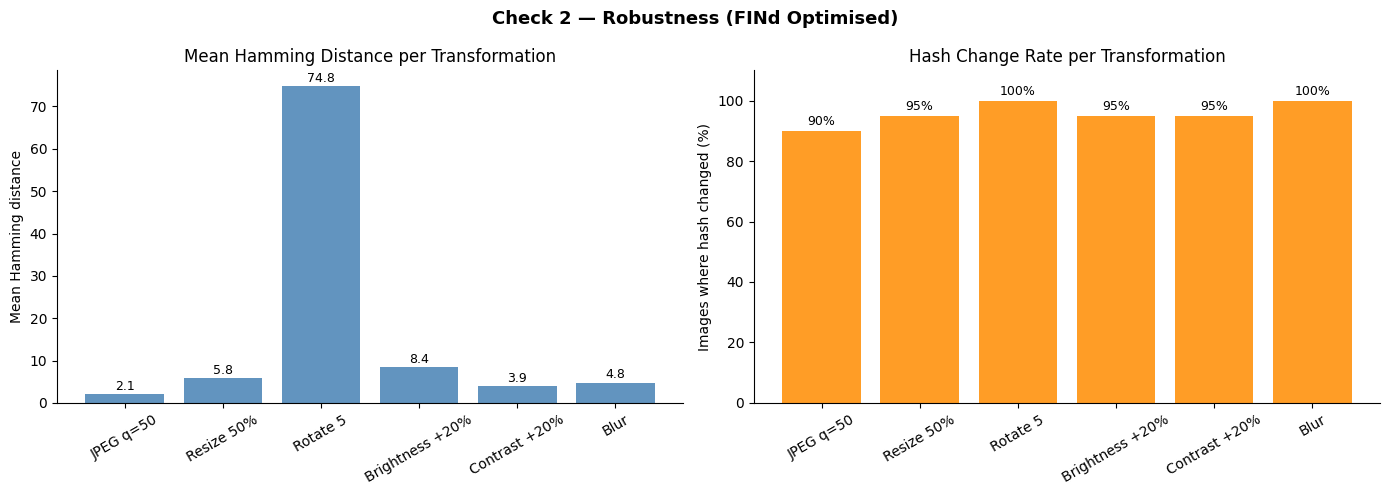

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

transform_names = list(results.keys())
means   = [np.mean(results[t]) for t in transform_names]
changed = [sum(d > 0 for d in results[t]) / len(results[t]) * 100 for t in transform_names]

ax1 = axes[0]
bars = ax1.bar(transform_names, means, color="steelblue", alpha=0.85)
ax1.set_ylabel("Mean Hamming distance")
ax1.set_title("Mean Hamming Distance per Transformation")
ax1.tick_params(axis="x", rotation=30)
for bar, v in zip(bars, means):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f"{v:.1f}", ha="center", va="bottom", fontsize=9)
for spine in ["top","right"]: ax1.spines[spine].set_visible(False)

ax2 = axes[1]
bars2 = ax2.bar(transform_names, changed, color="darkorange", alpha=0.85)
ax2.set_ylabel("Images where hash changed (%)")
ax2.set_title("Hash Change Rate per Transformation")
ax2.tick_params(axis="x", rotation=30)
ax2.set_ylim(0, 110)
for bar, v in zip(bars2, changed):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"{v:.0f}%", ha="center", va="bottom", fontsize=9)
for spine in ["top","right"]: ax2.spines[spine].set_visible(False)

plt.suptitle("Check 2 — Robustness (FINd Optimised)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "opt_check2_robustness.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Check 3 — Discrimination


In [5]:
N_PAIRS = 100

by_family = defaultdict(list)
for p in all_images:
    by_family[family(p)].append(p)

multi = [imgs for imgs in by_family.values() if len(imgs) >= 2]

random.shuffle(multi)
dup_dists = []
for imgs in multi[:N_PAIRS]:
    a, b = random.sample(imgs, 2)
    dup_dists.append(hasher.fromFile(str(a)) - hasher.fromFile(str(b)))

families = list(by_family.keys())
ndup_dists = []
for _ in range(N_PAIRS):
    f1, f2 = random.sample(families, 2)
    a = random.choice(by_family[f1])
    b = random.choice(by_family[f2])
    ndup_dists.append(hasher.fromFile(str(a)) - hasher.fromFile(str(b)))

print(f"Same-family      — mean: {np.mean(dup_dists):.1f}  std: {np.std(dup_dists):.1f}")
print(f"Different-family — mean: {np.mean(ndup_dists):.1f}  std: {np.std(ndup_dists):.1f}")

Same-family      — mean: 52.9  std: 18.1
Different-family — mean: 127.4  std: 9.1


/var/folders/j_/2r5hsbjx0dj5684gmxzqz9jm0000gn/T/ipykernel_48175/462947821.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot([dup_dists, ndup_dists], patch_artist=True,


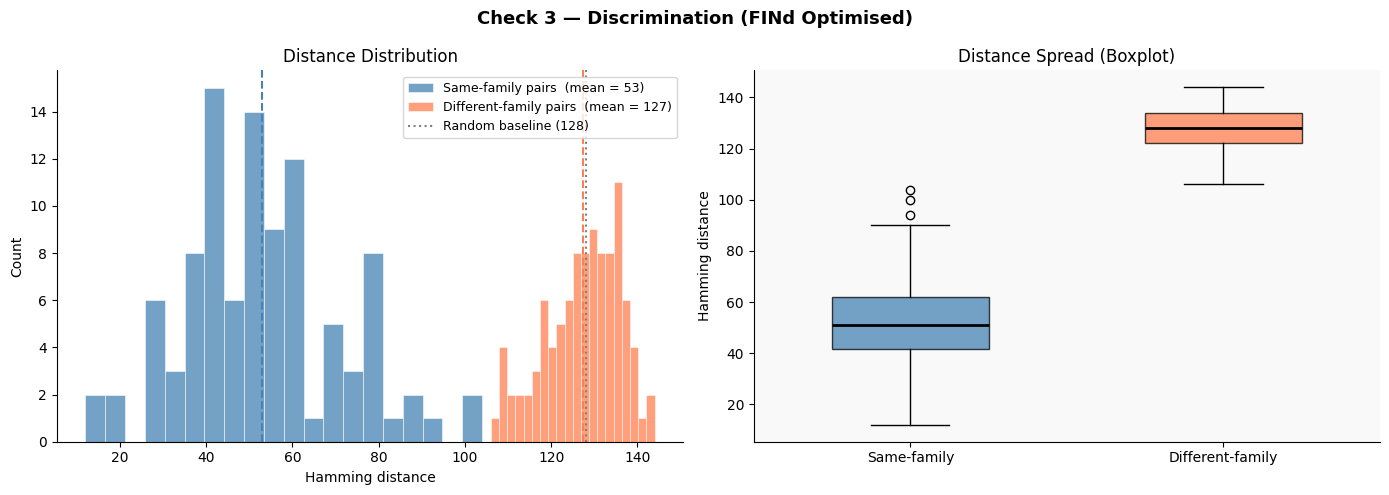

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dup_mean  = np.mean(dup_dists)
ndup_mean = np.mean(ndup_dists)

ax = axes[0]
ax.hist(dup_dists,  bins=20, alpha=0.75, color="steelblue",
        label=f"Same-family pairs  (mean = {dup_mean:.0f})", edgecolor="white", linewidth=0.5)
ax.hist(ndup_dists, bins=20, alpha=0.75, color="coral",
        label=f"Different-family pairs  (mean = {ndup_mean:.0f})", edgecolor="white", linewidth=0.5)
ax.axvline(dup_mean,  color="steelblue", linestyle="--", lw=1.5)
ax.axvline(ndup_mean, color="coral",     linestyle="--", lw=1.5)
ax.axvline(128, color="grey", linestyle=":", lw=1.5, label="Random baseline (128)")
ax.set_xlabel("Hamming distance")
ax.set_ylabel("Count")
ax.set_title("Distance Distribution")
ax.legend(fontsize=9)
for spine in ["top","right"]: ax.spines[spine].set_visible(False)

ax2 = axes[1]
bp = ax2.boxplot([dup_dists, ndup_dists], patch_artist=True,
                  labels=["Same-family", "Different-family"],
                  widths=0.5, medianprops=dict(color="black", lw=2))

for patch, color in zip(bp["boxes"], ["steelblue", "coral"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
ax2.set_ylabel("Hamming distance")
ax2.set_title("Distance Spread (Boxplot)")
ax2.set_facecolor("#f9f9f9")
for spine in ["top","right"]: ax2.spines[spine].set_visible(False)

plt.suptitle("Check 3 — Discrimination (FINd Optimised)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "opt_check3_discrimination.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Check 4 — Precision, Recall, F1

Sweeping Hamming distance thresholds from 0 to 256 to find the threshold that maximises F1. Pairs below the threshold are classified as duplicates (same family); above as non-duplicates(different family).

In [7]:
distances = np.array(dup_dists + ndup_dists)
labels    = np.array([1]*len(dup_dists) + [0]*len(ndup_dists))

rows = []
for thresh in range(0, 257):
    preds = (distances <= thresh).astype(int)
    tp = int(((preds == 1) & (labels == 1)).sum())
    fp = int(((preds == 1) & (labels == 0)).sum())
    fn = int(((preds == 0) & (labels == 1)).sum())
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
    rows.append({"threshold": thresh, "precision": prec, "recall": rec, "f1": f1})

thresh_df = pd.DataFrame(rows)
best = thresh_df.loc[thresh_df["f1"].idxmax()]
print(f"Best threshold : {int(best['threshold'])}")
print(f"Precision      : {best['precision']:.3f}")
print(f"Recall         : {best['recall']:.3f}")
print(f"F1             : {best['f1']:.3f}")

Best threshold : 104
Precision      : 1.000
Recall         : 1.000
F1             : 1.000


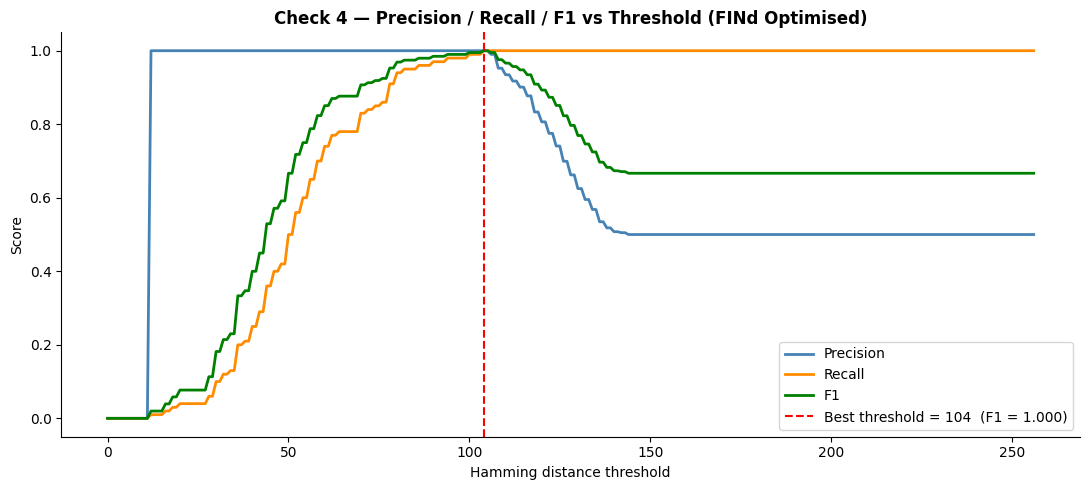

In [8]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(thresh_df["threshold"], thresh_df["precision"], color="steelblue",  lw=2, label="Precision")
ax.plot(thresh_df["threshold"], thresh_df["recall"],    color="darkorange", lw=2, label="Recall")
ax.plot(thresh_df["threshold"], thresh_df["f1"],        color="green",      lw=2, label="F1")
ax.axvline(best["threshold"], color="red", linestyle="--", lw=1.5,
           label=f"Best threshold = {int(best['threshold'])}  (F1 = {best['f1']:.3f})")
ax.set_xlabel("Hamming distance threshold")
ax.set_ylabel("Score")
ax.set_title("Check 4 — Precision / Recall / F1 vs Threshold (FINd Optimised)", fontweight="bold")
ax.legend(fontsize=10)
for spine in ["top","right"]: ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "opt_check4_prf1.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Step 2 — Computational Performance

Profiling the optimised hasher using the same methodology as `01_evaluation& ProfilingFINd.ipynb`: `timeit.repeat` for wall-clock time, `tracemalloc` for memory, and `cProfile` for function-level breakdown. 

In [10]:
import timeit, statistics, tracemalloc, cProfile, pstats

bench_images = random.sample(all_images, 20)
REPEATS = 10

timings = []
for p in bench_images:
    t = timeit.repeat(lambda path=str(p): hasher.fromFile(path), number=1, repeat=REPEATS)
    timings.append(min(t))

mean_ms   = statistics.mean(timings) * 1000
median_ms = statistics.median(timings) * 1000
print(f"Wall-clock time per image")
print(f"  Mean   : {mean_ms:.2f} ms    (original baseline: 114.65 ms)")
print(f"  Median : {median_ms:.2f} ms")
print(f"  Speedup: {114.65 / mean_ms:.2f}x")

Wall-clock time per image
  Mean   : 10.57 ms    (original baseline: 114.65 ms)
  Median : 10.53 ms
  Speedup: 10.84x


In [11]:
mem_images = random.sample(all_images, 10)
peaks = []
for p in mem_images:
    tracemalloc.start()
    hasher.fromFile(str(p))
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    peaks.append(peak / 1024)

print(f"Peak memory per image")
print(f"  Mean   : {statistics.mean(peaks):.1f} KB   (original baseline: 3,990 KB)")
print(f"  Median : {statistics.median(peaks):.1f} KB")

Peak memory per image
  Mean   : 8855.9 KB   (original baseline: 3,990 KB)
  Median : 8855.5 KB


In [12]:
img_path = str(random.choice(all_images))
REPS = 5

pr = cProfile.Profile()
pr.enable()
for _ in range(REPS):
    hasher.fromFile(img_path)
pr.disable()

buf = io.StringIO()
ps  = pstats.Stats(pr, stream=buf).sort_stats("cumulative")
ps.print_stats(12)
lines = buf.getvalue().splitlines()
print(f"\n=== cProfile — FINDHasher_optimized ({REPS} repetitions) ===")
print("\n".join(lines[4:18]))


=== cProfile — FINDHasher_optimized (5 repetitions) ===

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
      3/2    0.000    0.000    0.082    0.041 /opt/anaconda3/envs/FSDS/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3663(run_code)
      3/2    0.000    0.000    0.082    0.041 {built-in method builtins.exec}
        5    0.002    0.000    0.079    0.016 /Users/noha/Desktop/Hilary_term /DS in practice TA/FIN project/FINd_optimized.py:56(fromFile)
        5    0.000    0.000    0.076    0.015 /Users/noha/Desktop/Hilary_term /DS in practice TA/FIN project/FINd_optimized.py:64(fromImage)
        5    0.000    0.000    0.047    0.009 /Users/noha/Desktop/Hilary_term /DS in practice TA/FIN project/FINd_optimized.py:98(findHash256FromFloatLuma)
        5    0.030    0.006    0.038    0.008 /Users/noha/Desktop/Hilary_term /DS in practice TA/FIN project/FINd_optimized.py:171(boxFilter)
        5    0.027    0.005    0.028    0.006 /Users/noha/Desktop

---
## Step 3 — Test Suite

Running `tests/test_find_optimized.py` — 16 tests across 6 classes including the correctness contract: bit-identical output to the original FINDHasher on 20 diverse images.

In [13]:
import subprocess
result = subprocess.run(
    ["/opt/anaconda3/envs/FSDS/bin/pytest",
     "tests/test_find_optimized.py", "-v", "--tb=short"],
    capture_output=True, text=True,
    cwd=str(Path("../").resolve())
)
print(result.stdout)
if result.returncode != 0:
    print(result.stderr)

============================= test session starts ==============================
platform darwin -- Python 3.12.8, pytest-9.0.3, pluggy-1.6.0 -- /opt/anaconda3/envs/FSDS/bin/python3.12
cachedir: .pytest_cache
rootdir: /Users/noha/Desktop/Hilary_term /DS in practice TA/FIN project
collecting ... collected 16 items

tests/test_find_optimized.py::TestHashStructure::test_hash_is_256_bits PASSED [  6%]
tests/test_find_optimized.py::TestHashStructure::test_hash_contains_only_zeros_and_ones PASSED [ 12%]
tests/test_find_optimized.py::TestHashStructure::test_hash_is_not_all_zeros PASSED [ 18%]
tests/test_find_optimized.py::TestHashStructure::test_hash_is_not_all_ones PASSED [ 25%]
tests/test_find_optimized.py::TestDeterminism::test_same_file_twice_gives_identical_hash PASSED [ 31%]
tests/test_find_optimized.py::TestDeterminism::test_fromFile_and_fromImage_agree PASSED [ 37%]
tests/test_find_optimized.py::TestHammingDistance::test_identical_hashes_have_zero_distance PASSED [ 43%]
tests/test_fin